🧠 Classificação de Exames com Machine Learning

🎯 Objetivo
Desenvolver um modelo de classificação de riscos ou diagnósticos utilizando algoritmos de Machine Learning aplicados a uma base de dados relacionada à saúde feminina.

⭐ Extra (Opcional)
Além dos dados estruturados, pode-se incluir:
Classificação com dados de imagem (mamografias, ultrassons)
Uso de Redes Neurais Convolucionais (CNNs)
⚠️ Não obrigatório, mas pode aumentar a nota.

📊 Dados e Modelos

🔎 Escolha do Dataset
Selecionar um ou mais datasets públicos sobre:
Saúde da mulher
Segurança feminina
Descrever o problema que será resolvido

📈 Exploração de Dados (EDA)
 Carregamento da base de dados
 Análise das características gerais
 Estatísticas descritivas
 Visualizações relevantes

🔍 Análises importantes
Distribuição das variáveis
Relações entre features
Identificação de padrões ligados à saúde feminina

🧹 Pré-processamento de Dados
🔧 Limpeza
Tratamento de valores:
Ausentes
Inconsistentes

⚙️ Pipeline de Dados
 Criação de pipeline em Python
Transformações
 Conversão de variáveis categóricas
 Normalização/Padronização de variáveis numéricas

🔗 Correlação
Análise de correlação entre variáveis
Identificação de features relevantes

🤖 Modelagem

📌 Algoritmos
Utilizar 2 ou mais modelos de classificação, como:
Regressão Logística
Árvore de Decisão
KNN
(ou outros)

🔀 Divisão dos Dados
Separação clara entre:
Treino
Teste

📊 Treinamento e Avaliação

🏋️ Treinamento
 Treinar modelos com dados de treino

📏 Avaliação
 Avaliar com dados de teste
Métricas utilizadas
Accuracy
Recall
F1-score

🧠 Discussão
Justificar a escolha das métricas com base no problema
(ex: recall pode ser mais importante em diagnósticos médicos)

🔍 Interpretabilidade

📌 Técnicas utilizadas
Feature Importance
SHAP

🎯 Objetivo
Entender como o modelo toma decisões
Identificar quais variáveis mais influenciam o resultado
💭 Discussão Crítica
O modelo é confiável?
Pode ser usado na prática?

⚠️ Considerações importantes
O modelo deve auxiliar, não substituir o médico
Decisão final sempre deve ser de um profissional de saúde

In [1]:
#instalacoes necessárias
%pip install pandas
%pip install matplotlib scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================
# 📦 Manipulação de dados
# ================================
import pandas as pd
import numpy as np

# ================================
# 📊 Visualização
# ================================
import matplotlib.pyplot as plt
import matplotlib as mpl

# ================================
# 🤖 Modelos de Machine Learning
# ================================
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ================================
# 🔀 Divisão de dados
# ================================
from sklearn.model_selection import train_test_split

# ================================
# ⚙️ Pré-processamento
# ================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ================================
# 📏 Métricas de avaliação
# ================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ================================
# 🌳 Visualização de modelos
# ================================
from sklearn.tree import plot_tree
import seaborn as sns

In [3]:
# Criando o data frame a partir do arquivo csv
df = pd.read_csv('data.csv')

df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN



📈 Exploração de Dados (EDA)
 Carregamento da base de dados
 Análise das características gerais
 Estatísticas descritivas
 Visualizações relevantes

In [4]:
# Vizualizacao rápida
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Quantos registros existem de malignos e quantos de benignos?
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
# Entendendo a distribuicao em % de M e B 
df["diagnosis"].value_counts() / len(df)

diagnosis
B    0.627417
M    0.372583
Name: count, dtype: float64

In [7]:
# Gerando informacao sobre a tipagem dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [8]:
# Gerando informacao sobre a quantidade de linhas e colunas
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 's

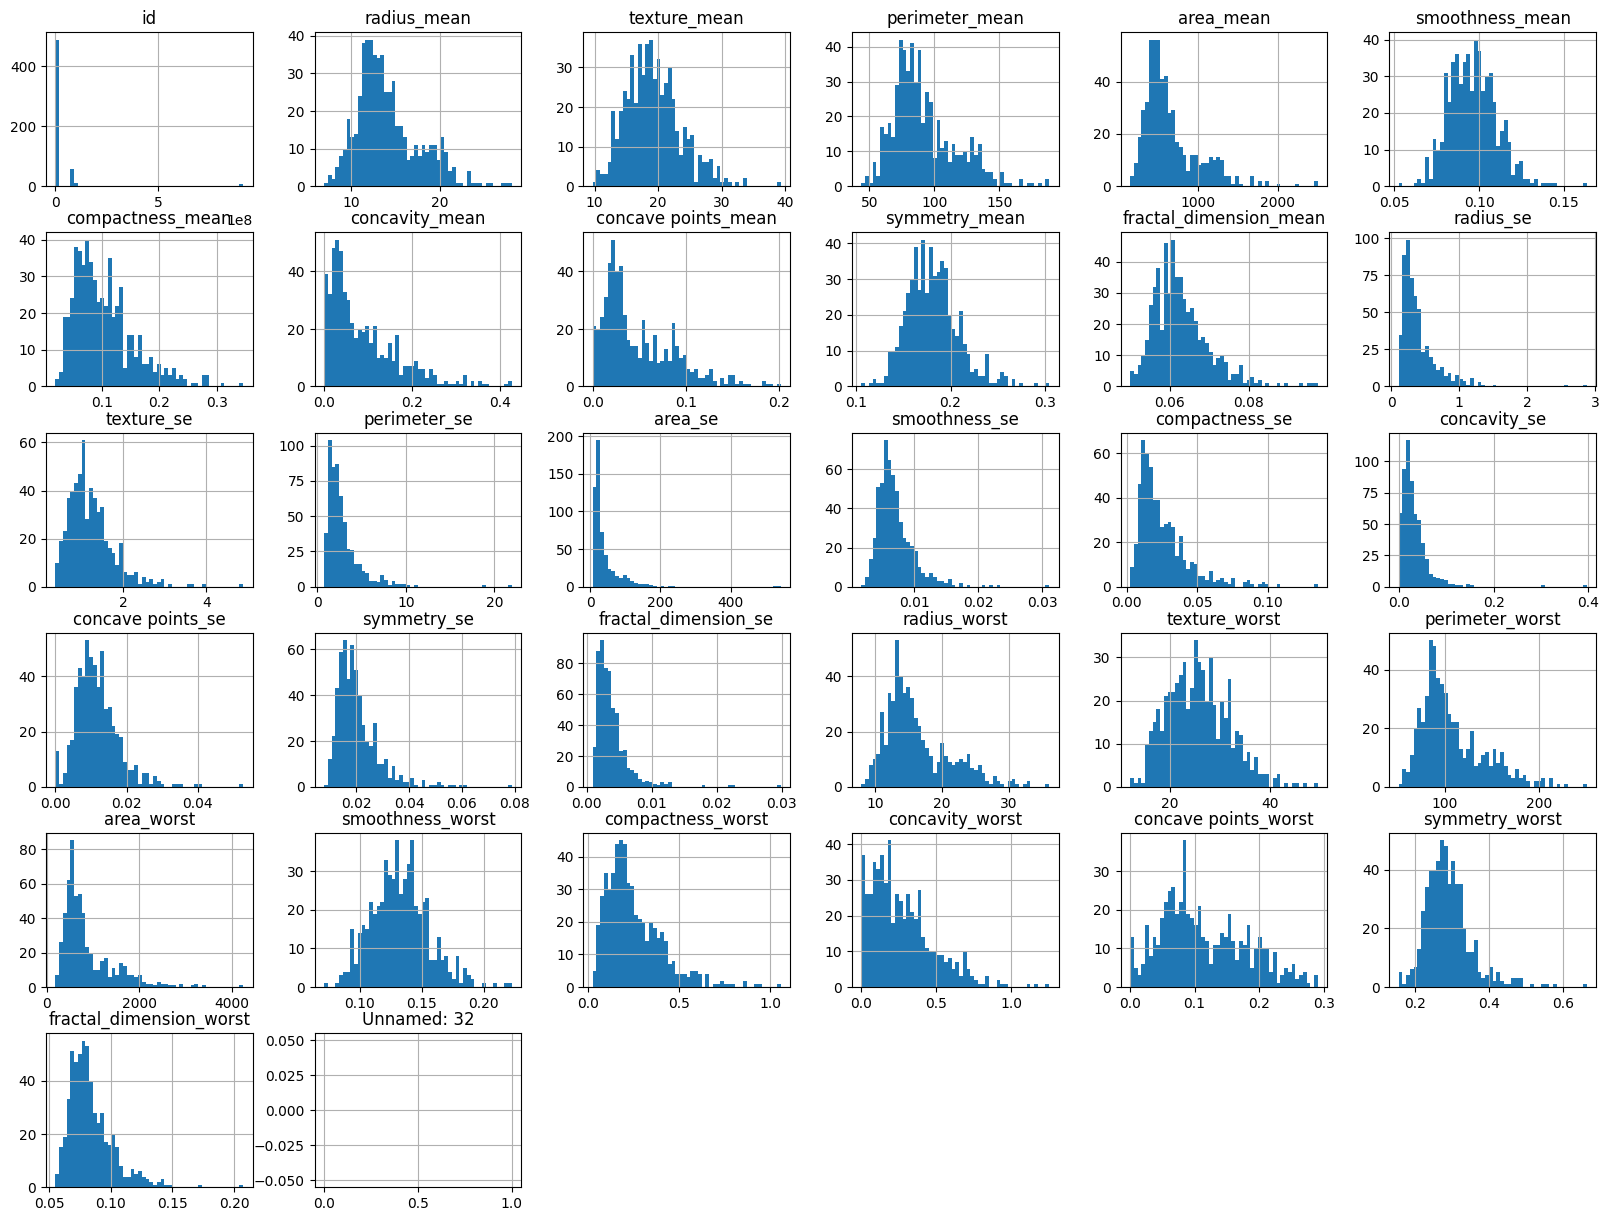

In [9]:
# Exibindo cada coluna como gráfico
df.hist(bins=50, figsize=(20, 15))

Notas: Alguns pontos relevantes antes de começar a entrar mais fundo na analise de relação entre cada uma das colunas.
1. Coluna ID deve ser removida, pois nao existe a necessidade de manter um indetificador para o propósito do treinamento do modelo
2. Por alguma razão ao converter o CSV em dataframe com o uso do pandas foi criado uma coluna extra no final chamada de Unnamed: 32, que por motivos obvios deve ser removida. 
3. Vou alterar o tipo dos valores da variavel target (diagnosis) para binário com o objetivo de facilitar a manipulacao dos dados e treinamentos futuros

In [10]:
# Removendo colunas desnecessarias
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

In [11]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
# Tratamento do dtype de diagnosis 
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})
print(df['diagnosis'].dtype)

int64


In [13]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
# Criacao do X e Y para manipulacao futura dos dados 

# X é tudo menos a variavel targer
X = df.drop(columns=['diagnosis'])

X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [15]:
# Y é somente a variável target
Y = df['diagnosis']

Y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [16]:
# Separar os df em teste e treino
df_train, df_test = train_test_split(
    df, test_size=0.12,
    random_state=6546,
    stratify=df['diagnosis'] # equilibrando os malignos e benignos entre treino e teste
)

print(len(df_train), "treinamento +", len(df_test), "teste")

500 treinamento + 69 teste


In [17]:
# Separar os X Y em teste e treino
X_train = df_train.drop('diagnosis', axis=1)
Y_train = df_train['diagnosis']

X_test = df_test.drop('diagnosis', axis=1)
Y_test = df_test['diagnosis']

In [18]:
print("=" * 50)
print("📊 DADOS DE TREINAMENTO E TESTE")
print("=" * 50)

print("\n🧠 X_train (Features de treino)")
print(f"Shape: {X_train.shape}")

print("\n🎯 Y_train (Target de treino)")
print(f"Shape: {Y_train.shape}")

print("\n🧪 X_test (Features de teste)")
print(f"Shape: {X_test.shape}")

print("\n🎯 Y_test (Target de teste)")
print(f"Shape: {Y_test.shape}")

📊 DADOS DE TREINAMENTO E TESTE

🧠 X_train (Features de treino)
Shape: (500, 30)

🎯 Y_train (Target de treino)
Shape: (500,)

🧪 X_test (Features de teste)
Shape: (69, 30)

🎯 Y_test (Target de teste)
Shape: (69,)


In [19]:

#sns.pairplot(
#    df,
#    hue='diagnosis',
#    diag_kind='hist'
#)

#plt.show()

Agora usar o standardScaler devido a disparidade entre os valores, existem valores de 0,2 e valores maiores que 100, e isso pode influenciar na hora do treinamento do modelo e acabar dando maior peso para os valores maiores.

In [20]:
scaler = StandardScaler()

X_train_sacalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [21]:
print("=" * 50)
print("⚙️ PADRONIZAÇÃO DOS DADOS")
print("=" * 50)

print("\n📚 Scaler utilizado:")
print(scaler)

print("\n🧠 X_train_scaled")
print(f"Shape: {X_train_sacalled.shape}")
print(X_train_sacalled[:5])

print("\n🧪 X_test_scaled")
print(f"Shape: {X_test_scalled.shape}")
print(X_test_scalled[:5])

⚙️ PADRONIZAÇÃO DOS DADOS

📚 Scaler utilizado:
StandardScaler()

🧠 X_train_scaled
Shape: (500, 30)
[[-1.50582021 -0.89511691 -1.4678407  -1.19319411 -0.9409271  -0.51409232
  -0.51953889 -0.64235301  0.47293788  0.48146929  0.53209614 -0.01242745
   0.78660097 -0.21927297  1.38703977  0.21958178  0.02279414  0.59079509
   1.07262163  0.14449084 -1.31833073 -1.30813588 -1.26775315 -1.04037274
  -1.3406921  -0.81496792 -0.8494489  -1.0139017  -0.75429657 -0.53911958]
 [ 0.27970007 -0.07364349  0.23620358  0.15297229 -0.28071683 -0.34046064
  -0.1635279  -0.12868208 -0.92478491 -0.51037611 -0.04810189 -0.01624705
  -0.09433168 -0.01312691 -0.71808804 -0.49963488 -0.05848719 -0.36811443
  -1.14059049 -0.76887034  0.28808725  0.35454198  0.21141888  0.17227556
  -0.33466936 -0.2804212   0.06994133 -0.03131195 -1.00320799 -0.79861194]
 [-0.13398982  0.88091781 -0.18728422 -0.22292621 -0.25851887 -0.69776722
  -0.74447602 -0.62605434 -0.53463465 -0.67053245 -0.20068519  0.2473054
  -0.3959989

Nossa ideia inicialmente foi utilizar Regressão Linear. Porém, após um estudo rápido sobre a finalidade e o funcionamento do algoritmo, entendemos que o problema proposto é de **classificação** e não de **regressão**. Por esse motivo, descartamos a utilização da Regressão Linear logo nas primeiras interações do projeto e optamos por não investir tempo em ajustes de parâmetros para melhorar seu desempenho.

Ainda assim, decidimos manter esse treinamento no código como forma de demonstrar nosso processo de aprendizado e entendimento das ferramentas utilizadas durante o desenvolvimento do trabalho. Inclusive, o resultado obtido (um score de 73.56%) não foi tão ruim considerando que o modelo basicamente tentou ajustar uma linha no plano cartesiano para resolver um problema de classificação.


In [22]:
# Treinamento de modelo usando regressao linear simples 

# Modelo
model= LinearRegression()

# Treinamento
model.fit(X_train, Y_train) 

# Score
model_score = model.score(X_test, Y_test) 
print(f"Score do modelo: {model_score*100:.2f}%")

Score do modelo: 73.56%


In [23]:
# Treinamento de modelo usando regressao linear simples com os dados escalados

# Modelo
model= LinearRegression()

# Treinamento
model.fit(X_train_sacalled, Y_train) 

# Score
model_score = model.score(X_test_scalled, Y_test) 
print(f"Score do modelo: {model_score*100:.2f}%")

Score do modelo: 73.56%


Fim da exploração com regressão linear

In [24]:
# Treinamento de modelo usando LogisticRegression

# Modelo
model = LogisticRegression()

# Treinamento
model.fit(X_train, Y_train)

# Previsões
Y_pred = model.predict(X_test)

# Métricas
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

# Print bonito
print("=" * 50)
print("🤖 RESULTADOS DO MODELO")
print("=" * 50)

print(f"\n🎯 Accuracy : {accuracy*100:.2f}%")
print(f"🎯 Precision: {precision*100:.2f}%")
print(f"🎯 Recall   : {recall*100:.2f}%")
print(f"🎯 F1-Score : {f1*100:.2f}%")

print("\n📊 Matriz de Confusão")
print(confusion_matrix(Y_test, Y_pred))

print("\n📋 Relatório Completo")
print(classification_report(Y_test, Y_pred))

print("\n" + "=" * 50)

🤖 RESULTADOS DO MODELO

🎯 Accuracy : 97.10%
🎯 Precision: 96.15%
🎯 Recall   : 96.15%
🎯 F1-Score : 96.15%

📊 Matriz de Confusão
[[42  1]
 [ 1 25]]

📋 Relatório Completo
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.96      0.96      0.96        26

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69




/Users/gabrielcannes/Documents/FIAP/desafio-tecnico-fase1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Treinamento de modelo usando LogisticRegression Escalado

# Modelo
model = LogisticRegression()

# Treinamento
model.fit(X_train_sacalled, Y_train)

# Previsões
Y_pred = model.predict(X_test_scalled)

# Métricas
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

# Print bonito
print("=" * 50)
print("🤖 RESULTADOS DO MODELO")
print("=" * 50)

print(f"\n🎯 Accuracy : {accuracy*100:.2f}%")
print(f"🎯 Precision: {precision*100:.2f}%")
print(f"🎯 Recall   : {recall*100:.2f}%")
print(f"🎯 F1-Score : {f1*100:.2f}%")

print("\n📊 Matriz de Confusão")
print(confusion_matrix(Y_test, Y_pred))

print("\n📋 Relatório Completo")
print(classification_report(Y_test, Y_pred))

print("\n" + "=" * 50)

🤖 RESULTADOS DO MODELO

🎯 Accuracy : 98.55%
🎯 Precision: 100.00%
🎯 Recall   : 96.15%
🎯 F1-Score : 98.04%

📊 Matriz de Confusão
[[43  0]
 [ 1 25]]

📋 Relatório Completo
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.96      0.98        26

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69


